In [1]:
pip install -q emantis baccoemu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.0/21.0 MB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.4/43.4 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 2.8 MB/s eta 0:00:00


# Angular Power Spectra: Galaxy Auto & CMB Lensing Cross-Correlation

This notebook computes galaxy auto-spectra $C_\ell^{gg}$ and galaxy–CMB lensing cross-spectra $C_\ell^{\kappa g}$ using the Limber approximation and standard line-of-sight (LOS) kernels, in both GR and $f(R)$ gravity.

**References:**
- [Lin et al. (2009)](https://arxiv.org/pdf/0804.3135)
- [Karim et al. (2025)](https://arxiv.org/pdf/2408.15909)
- [Lahav et al. (2004)](https://arxiv.org/pdf/astro-ph/0310642)
- [Bianchini et al. (2015)](https://arxiv.org/pdf/1410.4502)

## Cell 1 — Imports & Logging

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
import logging
import baccoemu
from emantis.matter_power_spectrum import NonLinearMGBoostEmulator
from scipy.interpolate import interp1d
from scipy.integrate import simpson, quad
import os
from contextlib import redirect_stdout, redirect_stderr
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u

warnings.simplefilter("ignore")
logging.getLogger("py.warnings").setLevel(logging.CRITICAL)

%matplotlib inline

## Cell 2 — Configuration

In [3]:
class Config:
    COSMO_PARAMS = {
        "Omega_m": 0.315,   # Total matter density parameter
        "Omega_b": 0.05,    # Baryon density parameter
        "h": 0.67,          # Reduced Hubble constant (H0 = 100h km/s/Mpc)
        "n_s": 0.96,        # Primordial scalar spectral index
        "sigma8": 0.83,     # RMS matter fluctuation amplitude at 8 Mpc/h
        "M_nu": 0.0,        # Sum of neutrino masses (eV)
        "w0": -1.0,         # Dark energy equation of state today
        "wa": 0.0,          # Time variation of dark energy equation of state
        "aexp": 1.0         # Scale factor (1.0 = present day)
    }

    TRANSFER_FUNCTION = "boltzmann_camb"  # Use Boltzmann solver (e.g., CAMB) for transfer function

    c = 299792.458        # Speed of light in km/s

# define the redshift grid for integrals

    Z_MIN = 0.01          # Minimum redshift
    Z_MAX = 3.0           # Maximum redshift
    N_Z = 500             # Number of redshift sampling points
    Z0_GALAXY = 0.3       # Characteristic galaxy redshift parameter

    ELL_MIN = 10          # Minimum multipole ℓ
    ELL_MAX = 2000        # Maximum multipole ℓ
    N_ELL = 50            # Number of ℓ sampling points

    BIAS_B0 = 2.0         # Linear galaxy bias parameter

    alpha = 2.225         # Magnification bias parameter (Karim et al., α ≃ 2.225)

    FR_VALUES = [4, 5, 6] # f(R) gravity parameter values (e.g., log10|fR0|)

    BACCO_K_MIN = -2      # Minimum log10(k) for power spectrum grid
    BACCO_K_MAX = None    # Maximum log10(k) (None = use default)
    BACCO_N_K = 200       # Number of k sampling points
    EMANTIS_VERBOSE = False  # Toggle emulator verbosity/logging

    FIGURE_SIZE = (14, 10)

    K_MIN_SAFETY = 1.1       # Safety factor for minimum k boundary
    K_MAX_SAFETY = 0.9       # Safety factor for maximum k boundary
    K_CLIP_THRESHOLD = 0.05  # Threshold for clipping unstable k values

## Cell 3 — Initialize Cosmology Parameters & Astropy Reference

Set up the cosmological parameters used throughout and create the matching
[Astropy `FlatLambdaCDM`](https://docs.astropy.org/en/stable/cosmology/index.html) object for validation.

In [4]:
# Initialize cosmology
H0 = Config.COSMO_PARAMS["h"] * 100.0  # km/s/Mpc
Om_m = Config.COSMO_PARAMS["Omega_m"]
Om_lambda = 1.0 - Om_m  # flat LCDM assumption for this run

# ── Astropy reference cosmology (used for validation throughout) ────
cosmo_astropy = FlatLambdaCDM(
    H0=H0,
    Om0=Om_m,
    Tcmb0=0.0,          # ignore radiation (consistent with notebook)
    Ob0=Config.COSMO_PARAMS["Omega_b"]
)
print(f"Astropy cosmology: {cosmo_astropy}")

# Comparison redshift grid
z_compare = np.linspace(0.01, 3.0, 200)

Astropy cosmology: FlatLambdaCDM(H0=67.0 km / (Mpc s), Om0=0.315, Tcmb0=0.0 K, Neff=3.04, m_nu=None, Ob0=0.05)


---
## Core Cosmological Functions

Each function is defined, immediately plotted, then validated against Astropy.

### Cell 4 — Hubble Function $H(z)$ & Comoving Distance $\chi(z)$

In [5]:
# Hubble Function (Eq. 1, Lin et al., 2009)
def hubble_function(z, H0, Om_m, Om_lambda):
    return H0 * np.sqrt(
        Om_m * (1 + z)**3 +
        (1 - Om_m - Om_lambda) * (1 + z)**2 +
        Om_lambda
    )

# Comoving Distance (Eq. 146, Lahav et al., 2004)
def comoving_distance_proper(z, H0, Om_m, Om_lambda):
    def integrand(z_prime):
        return Config.c / hubble_function(z_prime, H0, Om_m, Om_lambda)

    # Handle both scalar and array inputs
    if np.isscalar(z):
        chi, _ = quad(integrand, 0, z)
        return chi
    else:
        return np.array([quad(integrand, 0, z_val)[0] for z_val in z])

#### Plot & Astropy Validation — $H(z)$ and $\chi(z)$

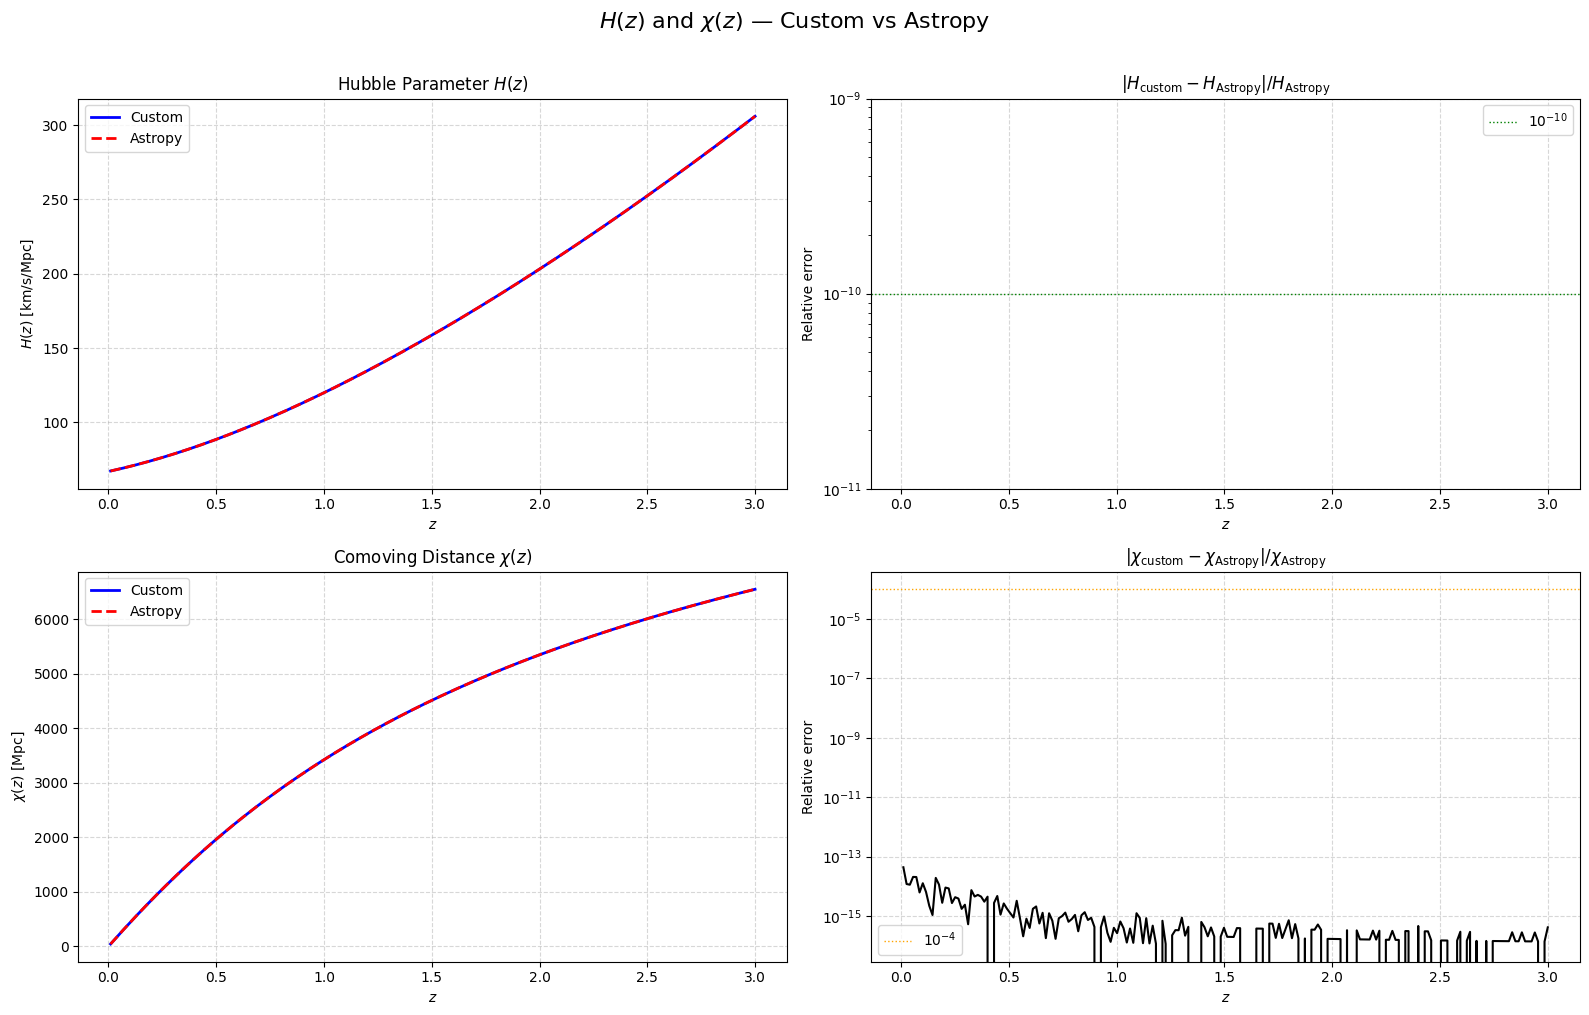

--- Validation: H(z) & χ(z) ---

  H(z=0) = 67.0000 km/s/Mpc  (expected H0 = 67.0000), rel err: 0.00e+00
  dH/dz|_{z=0}: numerical = 31.6577, analytic = 31.6575, rel err: 7.64e-06
  χ(z=0.001): numerical = 4.473457, Taylor = 4.474514, rel err: 2.36e-04

  Astropy H(z):  max rel err = 0.00e+00,  mean = 0.00e+00  PASS
  Astropy χ(z): max rel err = 4.39e-14, mean = 1.53e-15  PASS


In [6]:
# ── Compute ─────────────────────────────────────────────────────────
H_custom    = hubble_function(z_compare, H0, Om_m, Om_lambda)
H_astropy   = cosmo_astropy.H(z_compare).value

chi_custom  = comoving_distance_proper(z_compare, H0, Om_m, Om_lambda)
chi_astropy = cosmo_astropy.comoving_distance(z_compare).value

rel_err_H   = np.abs(H_custom  - H_astropy)  / H_astropy
rel_err_chi = np.abs(chi_custom - chi_astropy) / chi_astropy

# ── Plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(r"$H(z)$ and $\chi(z)$ — Custom vs Astropy", fontsize=16, y=1.01)

axes[0, 0].plot(z_compare, H_custom,  'b-',  lw=2, label='Custom')
axes[0, 0].plot(z_compare, H_astropy, 'r--', lw=2, label='Astropy')
axes[0, 0].set_xlabel(r'$z$'); axes[0, 0].set_ylabel(r'$H(z)$ [km/s/Mpc]')
axes[0, 0].set_title(r'Hubble Parameter $H(z)$'); axes[0, 0].legend(); axes[0, 0].grid(True, ls='--', alpha=0.5)

axes[0, 1].semilogy(z_compare, rel_err_H, 'k-', lw=1.5)
axes[0, 1].axhline(1e-10, color='green', ls=':', lw=1, label=r'$10^{-10}$')
axes[0, 1].set_xlabel(r'$z$'); axes[0, 1].set_ylabel('Relative error')
axes[0, 1].set_title(r'$|H_{\rm custom} - H_{\rm Astropy}| / H_{\rm Astropy}$')
axes[0, 1].legend(); axes[0, 1].grid(True, ls='--', alpha=0.5)

axes[1, 0].plot(z_compare, chi_custom,  'b-',  lw=2, label='Custom')
axes[1, 0].plot(z_compare, chi_astropy, 'r--', lw=2, label='Astropy')
axes[1, 0].set_xlabel(r'$z$'); axes[1, 0].set_ylabel(r'$\chi(z)$ [Mpc]')
axes[1, 0].set_title(r'Comoving Distance $\chi(z)$'); axes[1, 0].legend(); axes[1, 0].grid(True, ls='--', alpha=0.5)

axes[1, 1].semilogy(z_compare, rel_err_chi, 'k-', lw=1.5)
axes[1, 1].axhline(1e-4, color='orange', ls=':', lw=1, label=r'$10^{-4}$')
axes[1, 1].set_xlabel(r'$z$'); axes[1, 1].set_ylabel('Relative error')
axes[1, 1].set_title(r'$|\chi_{\rm custom} - \chi_{\rm Astropy}| / \chi_{\rm Astropy}$')
axes[1, 1].legend(); axes[1, 1].grid(True, ls='--', alpha=0.5)

plt.tight_layout(); plt.show()

# ── Taylor + Astropy summary ──────────────────────────────────────
print("--- Validation: H(z) & \u03c7(z) ---\n")
H_at_0 = hubble_function(0.0, H0, Om_m, Om_lambda)
print(f"  H(z=0) = {H_at_0:.4f} km/s/Mpc  (expected H0 = {H0:.4f}), rel err: {abs(H_at_0 - H0)/H0:.2e}")

dz = 1e-5
H_dz = hubble_function(dz, H0, Om_m, Om_lambda)
dHdz_numerical = (H_dz - H_at_0) / dz
dHdz_analytic  = H0 * (3 * Om_m) / 2.0
print(f"  dH/dz|_{{z=0}}: numerical = {dHdz_numerical:.4f}, analytic = {dHdz_analytic:.4f}, rel err: {abs(dHdz_numerical - dHdz_analytic)/abs(dHdz_analytic):.2e}")

z_small = 0.001
chi_small  = comoving_distance_proper(z_small, H0, Om_m, Om_lambda)
chi_taylor = Config.c * z_small / H0
print(f"  \u03c7(z={z_small}): numerical = {chi_small:.6f}, Taylor = {chi_taylor:.6f}, rel err: {abs(chi_small - chi_taylor)/chi_taylor:.2e}")

print(f"\n  Astropy H(z):  max rel err = {rel_err_H.max():.2e},  mean = {rel_err_H.mean():.2e}  "
      f"{'PASS' if rel_err_H.max() < 1e-6 else 'WARN'}")
print(f"  Astropy \u03c7(z): max rel err = {rel_err_chi.max():.2e}, mean = {rel_err_chi.mean():.2e}  "
      f"{'PASS' if rel_err_chi.max() < 1e-3 else 'WARN'}")

### Cell 5 — $\Omega(z)$, $\Lambda(z)$, Growth Function $g(z)$

In [7]:
# Omega(z) (Eq. 68, Lahav et al., 2004)
def compute_Omega_z(z, H0, Om_m, Om_lambda):
    num = Om_m * (1 + z)**3
    den = Om_m * (1 + z)**3 + (1 - Om_m - Om_lambda) * (1 + z)**2 + Om_lambda
    return num / den


# Lambda(z) (Eq. 69, Lahav et al., 2004)
def compute_lambda_z(z, H0, Om_m, Om_lambda):
    num = Om_lambda
    den = Om_m * (1 + z)**3 + (1 - Om_m - Om_lambda) * (1 + z)**2 + Om_lambda
    return num / den


# Growth Function g(z) (Eq. 67, Lahav et al., 2004)
def growth_function_g(z, H0, Om_m, Om_lambda):
    Omega_z = compute_Omega_z(z, H0, Om_m, Om_lambda)
    lambda_z = compute_lambda_z(z, H0, Om_m, Om_lambda)
    den = Omega_z**(4/7) - lambda_z + (1 + Omega_z/2) * (1 + lambda_z/70)
    return (5 * Omega_z / 2) * (1 / den)

#### Plot & Astropy Validation — $\Omega(z)$ and $\Lambda(z)$

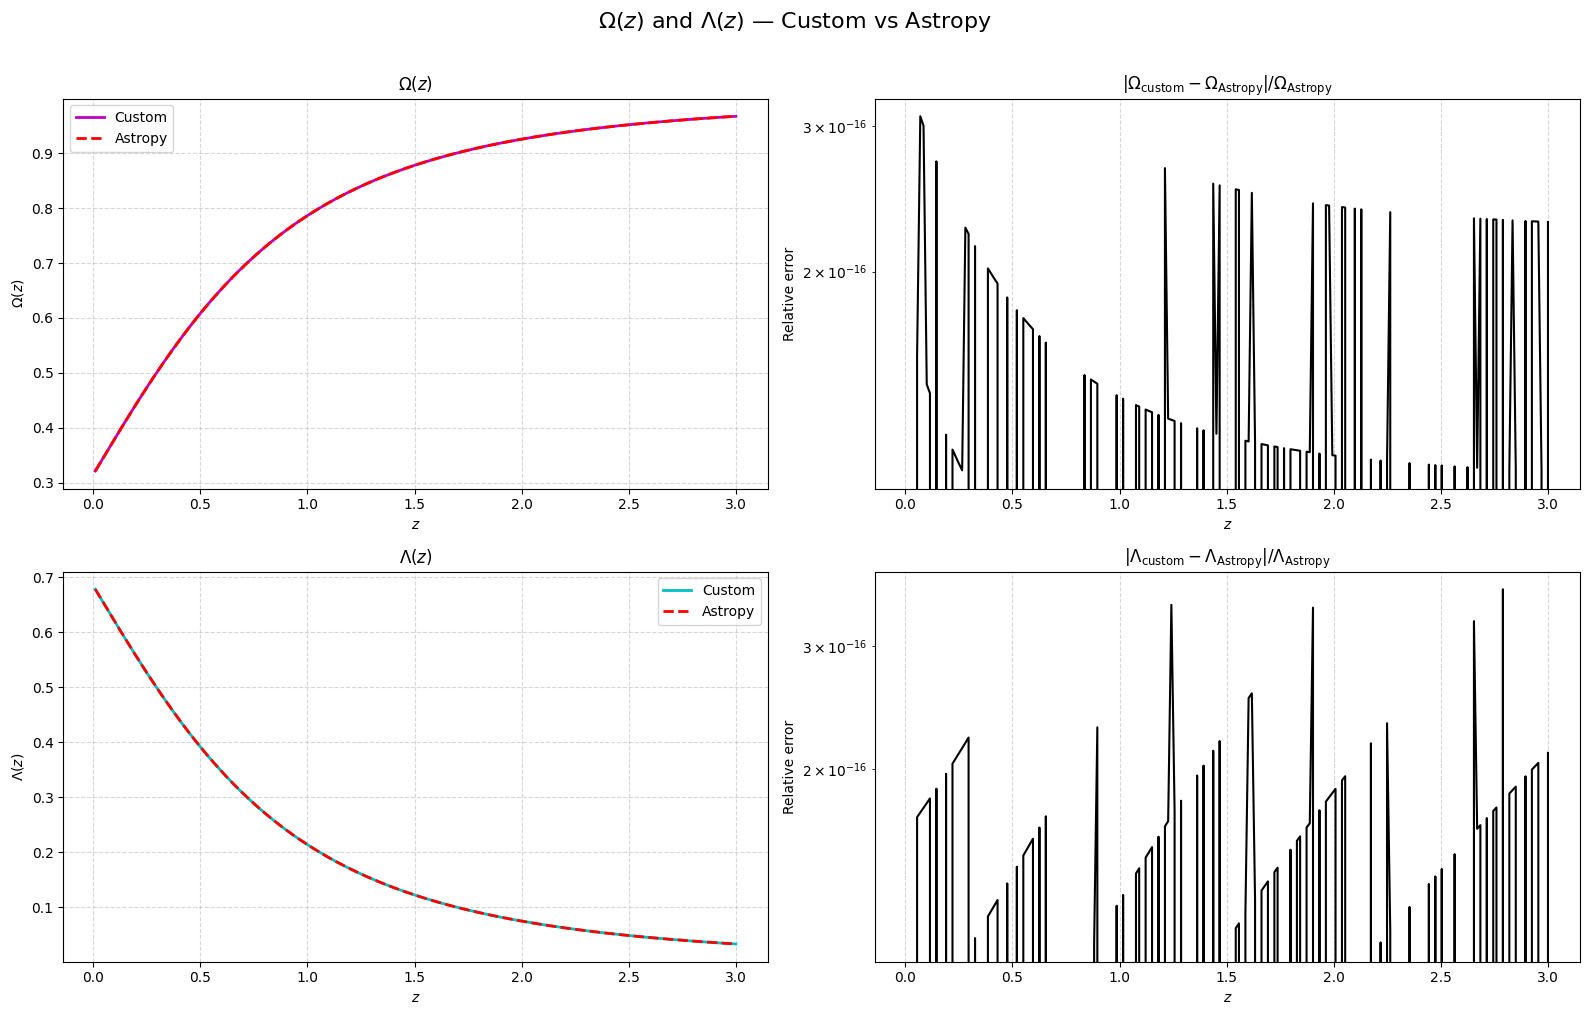

--- Validation: Ω(z) & Λ(z) ---

  Ω(z=0) = 0.315000  (expected 0.315000)
  Λ(z=0) = 0.685000  (expected 0.685000)
  Ω(z=100) = 0.999998  (expected → 1.0)

  Astropy Ω(z):  max rel err = 3.08e-16  PASS
  Astropy Λ(z): max rel err = 3.61e-16  PASS


In [8]:
# ── Compute ─────────────────────────────────────────────────────────
Omega_z_custom  = compute_Omega_z(z_compare, H0, Om_m, Om_lambda)
Lambda_z_custom = compute_lambda_z(z_compare, H0, Om_m, Om_lambda)

# Astropy: Om(z) = Om0*(1+z)^3 / E(z)^2,  Ode(z) via de_density_scale
E_z = cosmo_astropy.efunc(z_compare)
Omega_z_astropy  = Om_m * (1 + z_compare)**3 / E_z**2
Lambda_z_astropy = Om_lambda / E_z**2

rel_err_Om  = np.abs(Omega_z_custom  - Omega_z_astropy)  / Omega_z_astropy
rel_err_Lam = np.abs(Lambda_z_custom - Lambda_z_astropy) / Lambda_z_astropy

# ── Plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(r"$\Omega(z)$ and $\Lambda(z)$ — Custom vs Astropy", fontsize=16, y=1.01)

axes[0, 0].plot(z_compare, Omega_z_custom,  'm-',  lw=2, label='Custom')
axes[0, 0].plot(z_compare, Omega_z_astropy, 'r--', lw=2, label='Astropy')
axes[0, 0].set_xlabel(r'$z$'); axes[0, 0].set_ylabel(r'$\Omega(z)$')
axes[0, 0].set_title(r'$\Omega(z)$'); axes[0, 0].legend(); axes[0, 0].grid(True, ls='--', alpha=0.5)

axes[0, 1].semilogy(z_compare, rel_err_Om, 'k-', lw=1.5)
axes[0, 1].set_xlabel(r'$z$'); axes[0, 1].set_ylabel('Relative error')
axes[0, 1].set_title(r'$|\Omega_{\rm custom} - \Omega_{\rm Astropy}| / \Omega_{\rm Astropy}$')
axes[0, 1].grid(True, ls='--', alpha=0.5)

axes[1, 0].plot(z_compare, Lambda_z_custom,  'c-',  lw=2, label='Custom')
axes[1, 0].plot(z_compare, Lambda_z_astropy, 'r--', lw=2, label='Astropy')
axes[1, 0].set_xlabel(r'$z$'); axes[1, 0].set_ylabel(r'$\Lambda(z)$')
axes[1, 0].set_title(r'$\Lambda(z)$'); axes[1, 0].legend(); axes[1, 0].grid(True, ls='--', alpha=0.5)

axes[1, 1].semilogy(z_compare, rel_err_Lam, 'k-', lw=1.5)
axes[1, 1].set_xlabel(r'$z$'); axes[1, 1].set_ylabel('Relative error')
axes[1, 1].set_title(r'$|\Lambda_{\rm custom} - \Lambda_{\rm Astropy}| / \Lambda_{\rm Astropy}$')
axes[1, 1].grid(True, ls='--', alpha=0.5)

plt.tight_layout(); plt.show()

# ── Summary ───────────────────────────────────────────────────────
print("--- Validation: \u03a9(z) & \u039b(z) ---\n")
print(f"  \u03a9(z=0) = {compute_Omega_z(0., H0, Om_m, Om_lambda):.6f}  (expected {Om_m:.6f})")
print(f"  \u039b(z=0) = {compute_lambda_z(0., H0, Om_m, Om_lambda):.6f}  (expected {Om_lambda:.6f})")
print(f"  \u03a9(z=100) = {compute_Omega_z(100., H0, Om_m, Om_lambda):.6f}  (expected \u2192 1.0)")
print(f"\n  Astropy \u03a9(z):  max rel err = {rel_err_Om.max():.2e}  {'PASS' if rel_err_Om.max() < 1e-6 else 'WARN'}")
print(f"  Astropy \u039b(z): max rel err = {rel_err_Lam.max():.2e}  {'PASS' if rel_err_Lam.max() < 1e-6 else 'WARN'}")

### Cell 6 — Linear Growth Factor $D(z)$

In [9]:
# Linear growth factor D(z) (Eq. 66, Lahav et al. (2004))
def growth_factor_D(z, H0, Om_m, Om_lambda):  #need to modify

    # Handle both scalar and array inputs
    if np.isscalar(z):
        # ---- Step 1: Compute raw (unnormalized) growth ----
        g_z = growth_function_g(z, H0, Om_m, Om_lambda)
        D_z_raw = g_z / (1.0 + z)

        # ---- Step 2: Compute today's raw value ----
        g_0 = growth_function_g(0.0, H0, Om_m, Om_lambda)
        D_0_raw = g_0  # since (1+0) = 1

        # ---- Step 3: normalize so D(0) = 1 ----
        return D_z_raw / D_0_raw
    else:
        # For arrays, vectorize the computation
        g_z = np.array([growth_function_g(z_val, H0, Om_m, Om_lambda) for z_val in z])
        D_z_raw = g_z / (1.0 + z)

        g_0 = growth_function_g(0.0, H0, Om_m, Om_lambda)
        D_0_raw = g_0

        return D_z_raw / D_0_raw

#### Plot & Validation — $D(z)$

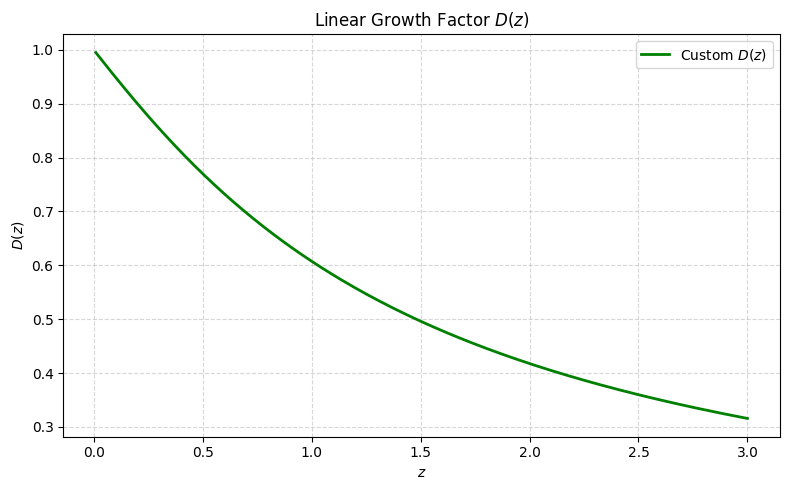

--- Validation: D(z) ---

  D(z=0) = 1.0000000000  (expected 1.0), abs err: 0.00e+00
  D(z) monotonically decreasing: PASS
  D(z=3) = 0.315746  (expected ~0.25 for this cosmology)


In [10]:
# ── Compute ─────────────────────────────────────────────────────────
D_custom = growth_factor_D(z_compare, H0, Om_m, Om_lambda)

# ── Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(z_compare, D_custom, 'g-', lw=2, label=r'Custom $D(z)$')
ax.set_xlabel(r'$z$'); ax.set_ylabel(r'$D(z)$')
ax.set_title(r'Linear Growth Factor $D(z)$')
ax.legend(); ax.grid(True, ls='--', alpha=0.5)
plt.tight_layout(); plt.show()

# ── Validation ────────────────────────────────────────────────────
# Note: Astropy does not provide a built-in D(z), so we validate via
# Taylor checks and by cross-checking the luminosity distance d_L(z)
# which depends on chi(z), already validated against Astropy above.
D_at_0 = growth_factor_D(0.0, H0, Om_m, Om_lambda)
print("--- Validation: D(z) ---\n")
print(f"  D(z=0) = {D_at_0:.10f}  (expected 1.0), abs err: {abs(D_at_0 - 1.0):.2e}")
print(f"  D(z) monotonically decreasing: {'PASS' if np.all(np.diff(D_custom) <= 0) else 'FAIL'}")
print(f"  D(z=3) = {D_custom[-1]:.6f}  (expected ~0.25 for this cosmology)")

### Cell 7 — CMB Lensing Kernel, Galaxy Lensing Kernel, Bias Function

In [11]:
# CMB Lensing Kernel W_k(z) (Eq. 4.2, Karim et al., 2025, Eqs. (3)-(4), Bianchini et al. (2015)) (#recheck)
def cmb_lensing_kernel(z, z_star, H0, Om_m, Om_lambda):
    prefactor = (3 * Om_m * (H0**2)/hubble_function(z, H0, Om_m, Om_lambda)) / (2 * Config.c)

    # Handle both scalar and array inputs
    if np.isscalar(z):
        chi_z = comoving_distance_proper(z, H0, Om_m, Om_lambda)
        chi_star = comoving_distance_proper(z_star, H0, Om_m, Om_lambda)
        return prefactor * (1 + z) * chi_z * (chi_star - chi_z) / chi_star
    else:
        chi_z = comoving_distance_proper(z, H0, Om_m, Om_lambda)
        chi_star = comoving_distance_proper(z_star, H0, Om_m, Om_lambda)
        return prefactor * (1 + z) * chi_z * (chi_star - chi_z) / chi_star


# Galaxy Lensing Kernel W_g(z) (Eq. 4.3 & 4.4, Karim et al., 2025, Eq. 6, Bianchini et al. (2015)) (#recheck)
def galaxy_lensing_kernel(z, z_array, dN_dz_func, bias_func, H0, Om_m, Om_lambda):
    bias_term = bias_func(z) * dN_dz_func(z)
    chi_z = comoving_distance_proper(z, H0, Om_m, Om_lambda)
    def integrand(z_prime):
        chi_z_prime = comoving_distance_proper(z_prime, H0, Om_m, Om_lambda)
        return (1 - chi_z / chi_z_prime) * (Config.alpha - 1) * dN_dz_func(z_prime)
    z_star = 10.0
    integral_term, _ = quad(integrand, z, z_star)
    mu_prefactor = (3 * Om_m * H0**2) / (2 * Config.c) * (1 + z) * chi_z
    mu_z = mu_prefactor * integral_term
    return bias_term + mu_z


# Bias Function (Eq. 4.7, Karim et al., 2025) #D*(z) represents the normalized growth factor
def bias_function(z, H0, Omega_m, Omega_lambda, b0=1.0):
    D_z = growth_factor_D(z, H0, Omega_m, Omega_lambda)
    D_0 = growth_factor_D(0, H0, Omega_m, Omega_lambda)
    D_star_z = D_z / D_0
    return b0 / (D_star_z + 1e-30)

#### Plot & Astropy Validation — $W_\kappa(z)$, $b(z)$, and $d_L(z)$ cross-check

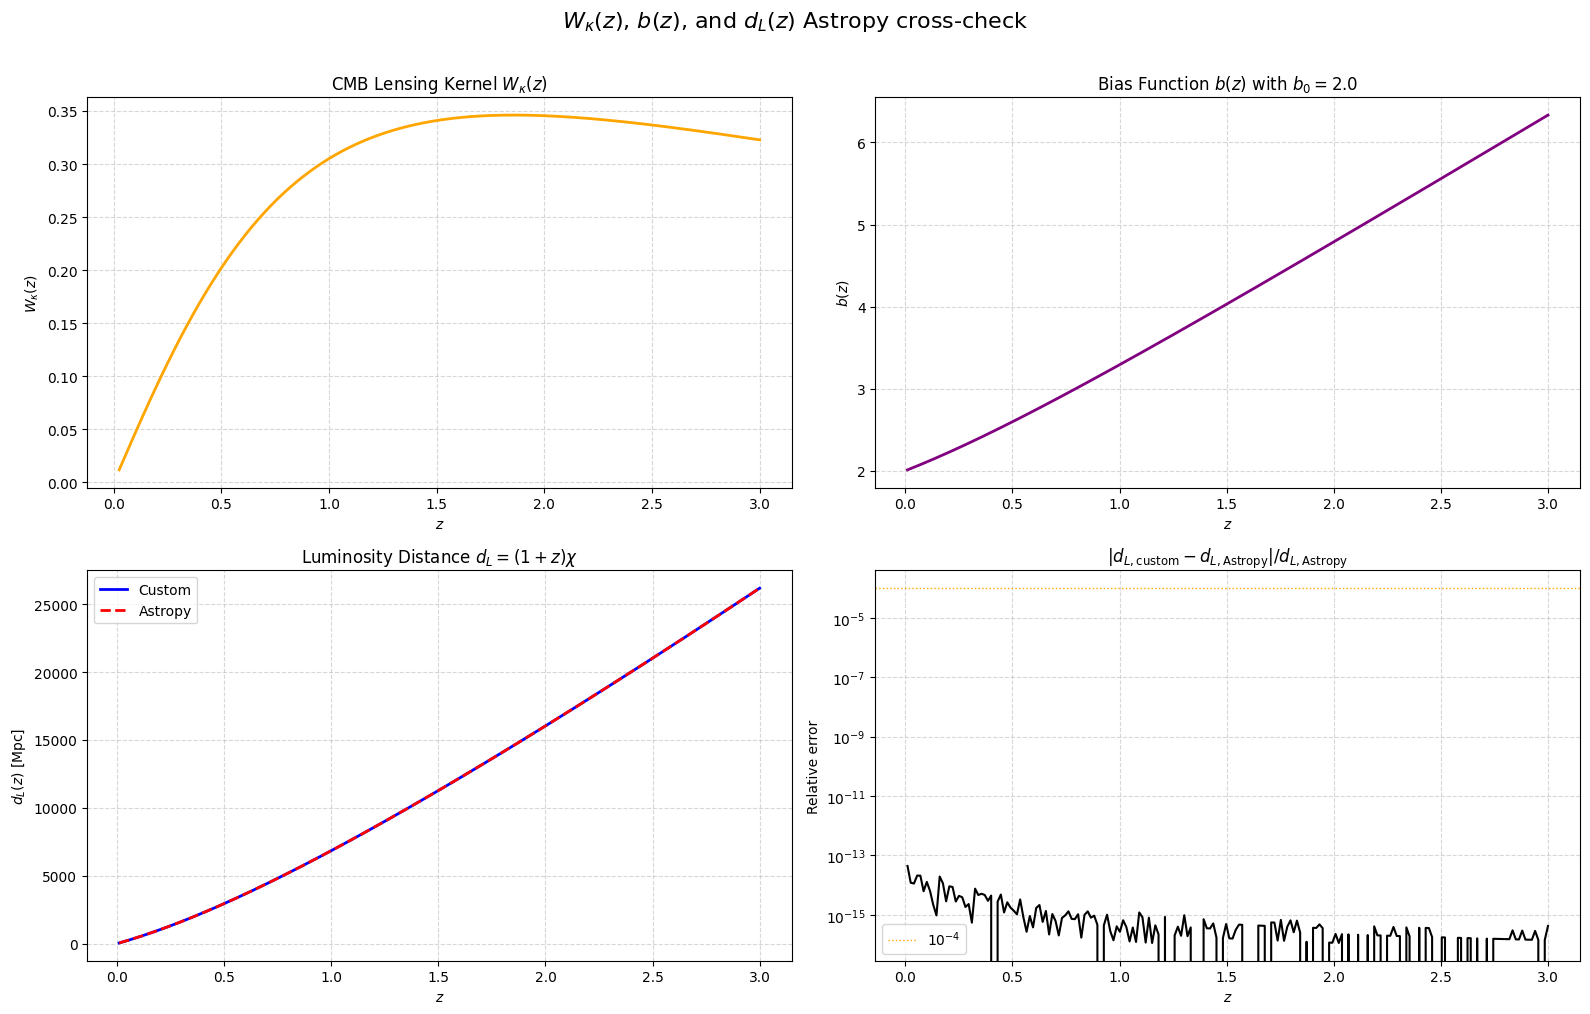

--- Validation: W_κ(z), b(z), d_L(z) ---

  W_κ(z) > 0 for 0 < z < z*: PASS
  b(z=0) = 2.000000  (expected b0 = 2.000000), rel err: 0.00e+00

  Astropy d_L(z): max rel err = 4.38e-14, mean = 1.52e-15  PASS


In [12]:
# ── Compute ─────────────────────────────────────────────────────────
z_star_val = 1100.0
z_plot = z_compare[1:]  # skip z=0 for chi

Wk_custom = cmb_lensing_kernel(z_plot, z_star_val, H0, Om_m, Om_lambda)
b_custom  = bias_function(z_compare, H0, Om_m, Om_lambda, b0=Config.BIAS_B0)

# Luminosity distance cross-check (depends on chi, already validated)
chi_for_dL  = comoving_distance_proper(z_compare, H0, Om_m, Om_lambda)
dL_custom   = (1 + z_compare) * chi_for_dL
dL_astropy  = cosmo_astropy.luminosity_distance(z_compare).value
rel_err_dL  = np.abs(dL_custom - dL_astropy) / dL_astropy

# ── Plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(r"$W_\kappa(z)$, $b(z)$, and $d_L(z)$ Astropy cross-check", fontsize=16, y=1.01)

axes[0, 0].plot(z_plot, Wk_custom, 'orange', lw=2)
axes[0, 0].set_xlabel(r'$z$'); axes[0, 0].set_ylabel(r'$W_\kappa(z)$')
axes[0, 0].set_title(r'CMB Lensing Kernel $W_\kappa(z)$'); axes[0, 0].grid(True, ls='--', alpha=0.5)

axes[0, 1].plot(z_compare, b_custom, 'purple', lw=2)
axes[0, 1].set_xlabel(r'$z$'); axes[0, 1].set_ylabel(r'$b(z)$')
axes[0, 1].set_title(rf'Bias Function $b(z)$ with $b_0={Config.BIAS_B0}$'); axes[0, 1].grid(True, ls='--', alpha=0.5)

axes[1, 0].plot(z_compare, dL_custom,  'b-',  lw=2, label='Custom')
axes[1, 0].plot(z_compare, dL_astropy, 'r--', lw=2, label='Astropy')
axes[1, 0].set_xlabel(r'$z$'); axes[1, 0].set_ylabel(r'$d_L(z)$ [Mpc]')
axes[1, 0].set_title(r'Luminosity Distance $d_L = (1+z)\chi$'); axes[1, 0].legend(); axes[1, 0].grid(True, ls='--', alpha=0.5)

axes[1, 1].semilogy(z_compare, rel_err_dL, 'k-', lw=1.5)
axes[1, 1].axhline(1e-4, color='orange', ls=':', lw=1, label=r'$10^{-4}$')
axes[1, 1].set_xlabel(r'$z$'); axes[1, 1].set_ylabel('Relative error')
axes[1, 1].set_title(r'$|d_{L,\rm custom} - d_{L,\rm Astropy}| / d_{L,\rm Astropy}$')
axes[1, 1].legend(); axes[1, 1].grid(True, ls='--', alpha=0.5)

plt.tight_layout(); plt.show()

# ── Summary ───────────────────────────────────────────────────────
print("--- Validation: W_\u03ba(z), b(z), d_L(z) ---\n")
print(f"  W_\u03ba(z) > 0 for 0 < z < z*: {'PASS' if np.all(Wk_custom > 0) else 'WARN'}")
b_at_0 = bias_function(0.0, H0, Om_m, Om_lambda, b0=Config.BIAS_B0)
print(f"  b(z=0) = {b_at_0:.6f}  (expected b0 = {Config.BIAS_B0:.6f}), rel err: {abs(b_at_0 - Config.BIAS_B0)/Config.BIAS_B0:.2e}")
print(f"\n  Astropy d_L(z): max rel err = {rel_err_dL.max():.2e}, mean = {rel_err_dL.mean():.2e}  "
      f"{'PASS' if rel_err_dL.max() < 1e-3 else 'WARN'}")

---
## Power Spectrum Utilities (BACCO / EMANTIS)

### Cell 8 — Emulator Initialization Functions

In [13]:
def initialize_bacco_emulator(params, k_min=-2, k_max=None, n_k=200, verbose=False):
    """Initialize BACCO emulator for matter power spectrum."""
    with open(os.devnull, 'w') as fnull:
        with redirect_stdout(fnull), redirect_stderr(fnull):
            emulator = baccoemu.Matter_powerspectrum(verbose=verbose)

            if k_max is None:
                k_max = np.log10(emulator.emulator['nonlinear']['k'].max())

            k = np.logspace(k_min, k_max, num=n_k)

            params_bacco = {
                "omega_cold": params["Omega_m"] - params["Omega_b"],
                "sigma8_cold": params["sigma8"],
                "omega_baryon": params["Omega_b"],
                "ns": params["n_s"],
                "hubble": params["h"],
                "neutrino_mass": params.get("M_nu", 0.0),
                "w0": params.get("w0", -1.0),
                "wa": params.get("wa", 0.0),
                "expfactor": params.get("aexp", 1.0)
            }

            k, Q_boost = emulator.get_nonlinear_boost(k=k, cold=False, **params_bacco)
            k, pk_nl = emulator.get_nonlinear_pk(k=k, cold=False, **params_bacco)

    return k, pk_nl, Q_boost


def initialize_emantis_emulator(verbose=False):
    """Initialize EMANTIS emulator for f(R) gravity boost."""
    return NonLinearMGBoostEmulator(verbose=verbose)


def compute_fR_boost(emantis_emu, params, logfR0, k, aexp=1.0):
    """Compute f(R) gravity boost."""
    params_emantis = {
        "Omega_m": params["Omega_m"],
        "Omega_b": params["Omega_b"],
        "h": params["h"],
        "n_s": params["n_s"],
        "sigma8_lcdm": params["sigma8"],
        "logfR0": logfR0
    }
    return emantis_emu.predict_boost(params_emantis, aexp=aexp, k=k)

### Cell 9 — Power Spectrum Interpolator & k-bounds Helper

In [14]:
# Build log-log cubic interpolator for P(k) to evaluate at arbitrary k = l/chi(z)
# Convert discrete emulator P(k) into a smooth function (log-log interpolation)
# Use log-log space so P(k) interpolation is stable, smooth, and preserves power-law behavior

def create_power_spectrum_interpolator(k, pk):
    """Create log-log interpolator for P(k)."""
    return interp1d(
        np.log(k),
        np.log(pk + 1e-50),
        kind='cubic',
        bounds_error=False,
        fill_value='extrapolate'
    )


def check_k_bounds(k_vals, k_min, k_max, ell, spectrum_name, threshold=0.05):
    """Clip k values to safe bounds (simple version)."""
    return np.clip(k_vals, k_min, k_max)

### Cell 10 — Initialize Emulators & GR Power Spectrum

In [15]:
k, pk_nl_gr, Q_boost = initialize_bacco_emulator(
    Config.COSMO_PARAMS,
    k_min=Config.BACCO_K_MIN,
    k_max=Config.BACCO_K_MAX,
    n_k=Config.BACCO_N_K,
    verbose=Config.EMANTIS_VERBOSE
)
pk_interp_gr = create_power_spectrum_interpolator(k, pk_nl_gr)

emantis_emu = initialize_emantis_emulator(verbose=Config.EMANTIS_VERBOSE)

print("=" * 60)
print("Power Spectrum Interpolator")
print("=" * 60)
print(f"  k range: [{k.min():.4e}, {k.max():.4e}] h/Mpc")
print(f"  Number of k points: {len(k)}")
print(f"  P(k) range: [{pk_nl_gr.min():.4e}, {pk_nl_gr.max():.4e}] (Mpc/h)^3")

100% (358400 of 358400) |################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (1658880 of 1658880) |##############| Elapsed Time: 0:00:00 Time:  0:00:00
100% (1658880 of 1658880) |##############| Elapsed Time: 0:00:00 Time:  0:00:00
100% (2304000 of 2304000) |##############| Elapsed Time: 0:00:00 Time:  0:00:00
100% (2785280 of 2785280) |##############| Elapsed Time: 0:00:00 Time:  0:00:00
100% (2293760 of 2293760) |##############| Elapsed Time: 0:00:00 Time:  0:00:00


Power Spectrum Interpolator
  k range: [1.0000e-02, 4.9032e+00] h/Mpc
  Number of k points: 200
  P(k) range: [4.1270e+01, 3.7475e+04] (Mpc/h)^3


#### Plot & Validation — Interpolator Diagnostic

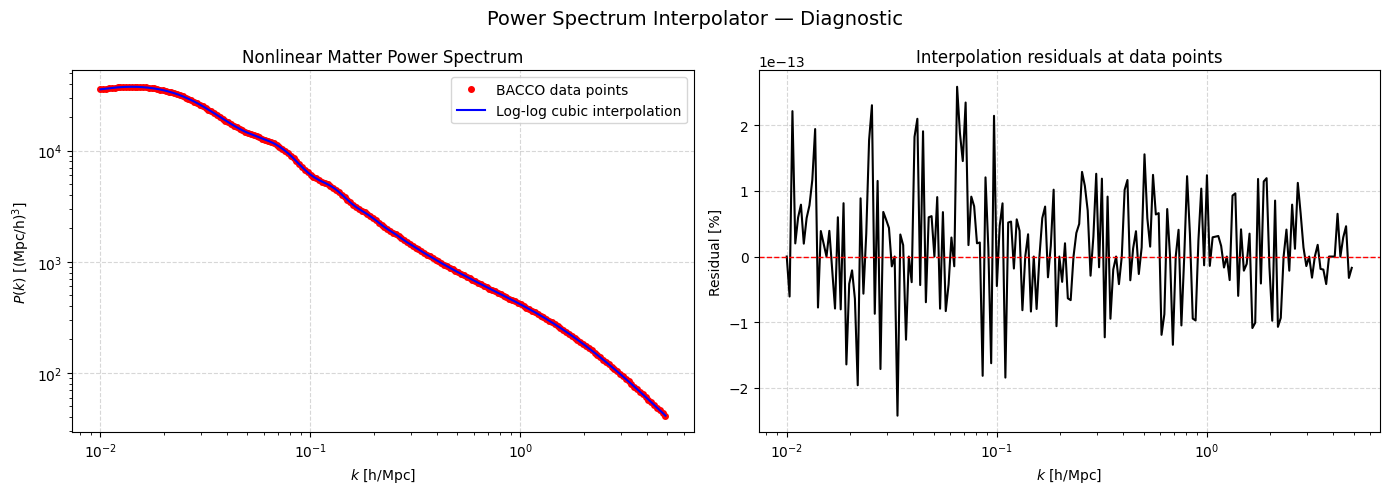

--- Validation: Power Spectrum Interpolator ---

  Max |residual| at data points: 2.59e-15
  Mean |residual| at data points: 6.60e-16
  Interpolator faithfully reproduces data: PASS

  Effective spectral index at small k (n_eff ~ n_s): -0.553
  (Expected near n_s = 0.96)

  P(k) > 0 everywhere: PASS


In [16]:
fig_interp, axes_interp = plt.subplots(1, 2, figsize=(14, 5))
fig_interp.suptitle("Power Spectrum Interpolator — Diagnostic", fontsize=14)

# Panel 1: P(k) raw data + interpolation
k_fine = np.logspace(np.log10(k.min()), np.log10(k.max()), 1000)
pk_interp_vals = np.exp(pk_interp_gr(np.log(k_fine)))

axes_interp[0].loglog(k, pk_nl_gr, 'ro', ms=4, label='BACCO data points')
axes_interp[0].loglog(k_fine, pk_interp_vals, 'b-', lw=1.5, label='Log-log cubic interpolation')
axes_interp[0].set_xlabel(r'$k$ [h/Mpc]')
axes_interp[0].set_ylabel(r'$P(k)$ [(Mpc/h)$^3$]')
axes_interp[0].set_title('Nonlinear Matter Power Spectrum')
axes_interp[0].legend()
axes_interp[0].grid(True, ls='--', alpha=0.5)

# Panel 2: Residuals (interpolated at data points vs data)
pk_at_data = np.exp(pk_interp_gr(np.log(k)))
residuals = (pk_at_data - pk_nl_gr) / pk_nl_gr
axes_interp[1].semilogx(k, residuals * 100, 'k-', lw=1.5)
axes_interp[1].axhline(0, color='r', ls='--', lw=1)
axes_interp[1].set_xlabel(r'$k$ [h/Mpc]')
axes_interp[1].set_ylabel('Residual [%]')
axes_interp[1].set_title('Interpolation residuals at data points')
axes_interp[1].grid(True, ls='--', alpha=0.5)

plt.tight_layout()
plt.show()

# ── Validation ────────────────────────────────────────────────────
print("--- Validation: Power Spectrum Interpolator ---\n")

max_resid = np.max(np.abs(residuals))
mean_resid = np.mean(np.abs(residuals))
print(f"  Max |residual| at data points: {max_resid:.2e}")
print(f"  Mean |residual| at data points: {mean_resid:.2e}")
print(f"  Interpolator faithfully reproduces data: {'PASS' if max_resid < 1e-10 else 'WARN'}")

k_small_idx = k < 0.05
if np.sum(k_small_idx) > 2:
    log_slope = np.diff(np.log(pk_nl_gr[k_small_idx])) / np.diff(np.log(k[k_small_idx]))
    print(f"\n  Effective spectral index at small k (n_eff ~ n_s): {np.mean(log_slope):.3f}")
    print(f"  (Expected near n_s = {Config.COSMO_PARAMS['n_s']})")

print(f"\n  P(k) > 0 everywhere: {'PASS' if np.all(pk_nl_gr > 0) else 'FAIL'}")

#### Interpolation Validation — Accuracy and Smoothness

**Held-Out Test:** Remove every other point from the BACCO grid, rebuild the interpolator on the remaining points,  
and evaluate it at the **held-out** points to compare against the true $P(k)$ values, measuring genuine interpolation accuracy.  

**Midpoint Test:** Predict values at midpoints between existing grid points using the full interpolator,  
then compare to a dense reference to check smoothness and out-of-sample consistency.

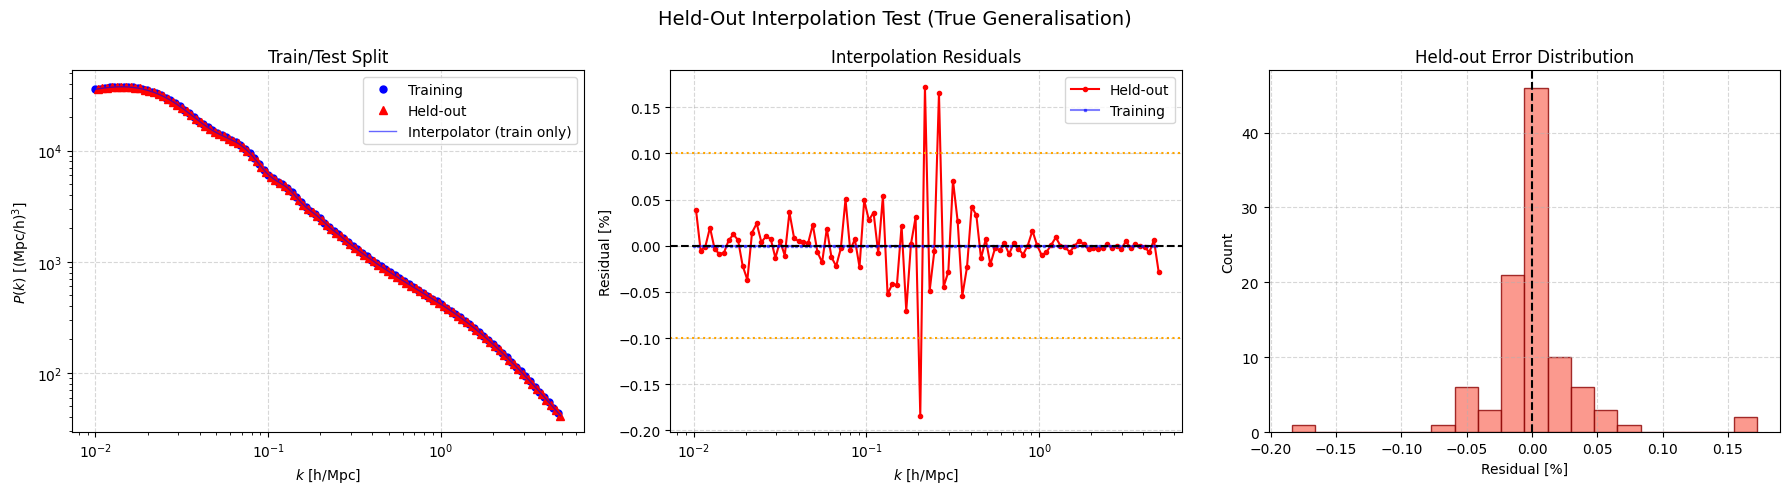

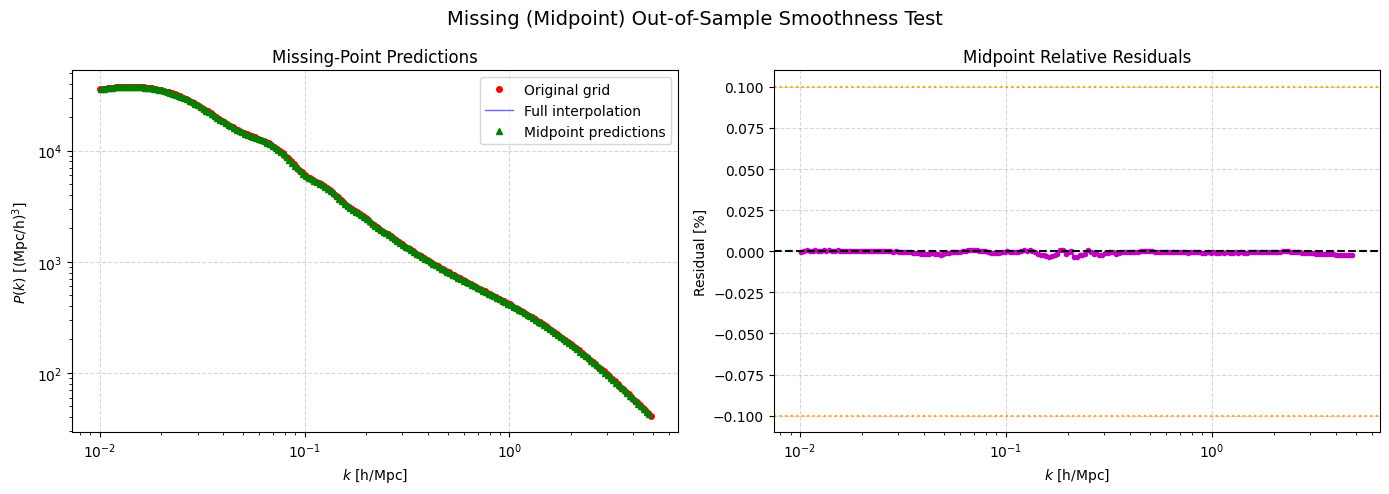


═══════════════════════════════════════════
        INTERPOLATION VALIDATION SUMMARY
═══════════════════════════════════════════

Held-out (true reconstruction) test:
  Training points     : 100
  Held-out points     : 100
  Max  |residual|     : 0.1840 %
  Mean |residual|     : 0.0204 %
  RMS  residual       : 0.0377 %
  <1% accuracy        : PASS

Midpoint (smoothness) test:
  Missing points      : 199
  Max  |residual|     : 0.0038 %
  Mean |residual|     : 0.0008 %
  <0.1% everywhere    : PASS

═══════════════════════════════════════════


In [27]:
# ══════════════════════════════════════════════════════════════════════
#        COMBINED INTERPOLATION VALIDATION SUITE
#        (1) Held-out reconstruction test
#        (2) Missing mid-point smoothness test
# ══════════════════════════════════════════════════════════════════════

# ----------------------------------------------------------------------
# 1️⃣  HELD-OUT TEST (Even indices train, odd test)
# ----------------------------------------------------------------------
idx_train = np.arange(0, len(k), 2)
idx_test  = np.arange(1, len(k), 2)

k_train, pk_train = k[idx_train], pk_nl_gr[idx_train]
k_test,  pk_test  = k[idx_test],  pk_nl_gr[idx_test]

# Rebuild interpolator on TRAINING ONLY
pk_interp_heldout = create_power_spectrum_interpolator(k_train, pk_train)

# Predictions
pk_pred_train = np.exp(pk_interp_heldout(np.log(k_train)))
pk_pred_test  = np.exp(pk_interp_heldout(np.log(k_test)))

residuals_train   = (pk_pred_train - pk_train) / pk_train
residuals_heldout = (pk_pred_test  - pk_test)  / pk_test

# Dense curve for visualization
k_dense = np.logspace(np.log10(k.min()), np.log10(k.max()), 1000)
pk_dense_heldout = np.exp(pk_interp_heldout(np.log(k_dense)))

# ── Plot: Held-out test ──────────────────────────────────────────────
fig1, axes1 = plt.subplots(1, 3, figsize=(18, 5))
fig1.suptitle("Held-Out Interpolation Test (True Generalisation)", fontsize=14)

# Panel 1: Train/Test split
axes1[0].loglog(k_train, pk_train, 'bo', ms=5, label='Training')
axes1[0].loglog(k_test,  pk_test,  'r^', ms=6, label='Held-out')
axes1[0].loglog(k_dense, pk_dense_heldout, 'b-', lw=1, alpha=0.6,
                label='Interpolator (train only)')
axes1[0].set_xlabel(r'$k$ [h/Mpc]')
axes1[0].set_ylabel(r'$P(k)$ [(Mpc/h)$^3$]')
axes1[0].set_title('Train/Test Split')
axes1[0].legend()
axes1[0].grid(True, ls='--', alpha=0.5)

# Panel 2: Residuals
axes1[1].semilogx(k_test, residuals_heldout * 100, 'r-o', ms=3, label='Held-out')
axes1[1].semilogx(k_train, residuals_train * 100, 'b-s', ms=2, alpha=0.5, label='Training')
axes1[1].axhline(0, color='k', ls='--')
axes1[1].axhline( 0.1, color='orange', ls=':')
axes1[1].axhline(-0.1, color='orange', ls=':')
axes1[1].set_xlabel(r'$k$ [h/Mpc]')
axes1[1].set_ylabel('Residual [%]')
axes1[1].set_title('Interpolation Residuals')
axes1[1].legend()
axes1[1].grid(True, ls='--', alpha=0.5)

# Panel 3: Histogram
axes1[2].hist(residuals_heldout * 100, bins=20,
              color='salmon', edgecolor='darkred', alpha=0.8)
axes1[2].axvline(0, color='k', ls='--')
axes1[2].set_xlabel('Residual [%]')
axes1[2].set_ylabel('Count')
axes1[2].set_title('Held-out Error Distribution')
axes1[2].grid(True, ls='--', alpha=0.5)

plt.tight_layout()
plt.show()


# ----------------------------------------------------------------------
# 2️⃣  MIDPOINT (OUT-OF-SAMPLE) TEST
# ----------------------------------------------------------------------

# Midpoints in log-space
log_k = np.log(k)
log_k_mid = 0.5 * (log_k[:-1] + log_k[1:])
k_missing = np.exp(log_k_mid)

# Use FULL interpolator (already built as pk_interp_gr)
pk_interp_missing = np.exp(pk_interp_gr(log_k_mid))

# Build dense reference
k_ref_dense  = np.logspace(np.log10(k.min()), np.log10(k.max()), len(k) * 5)
pk_ref_dense = np.exp(pk_interp_gr(np.log(k_ref_dense)))

# Reference at missing points
pk_ref_at_missing = np.interp(k_missing, k_ref_dense, pk_ref_dense)

residuals_missing = (pk_interp_missing - pk_ref_at_missing) / pk_ref_at_missing

# ── Plot: Missing-point test ─────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle("Missing (Midpoint) Out-of-Sample Smoothness Test", fontsize=14)

# Panel 1: P(k)
axes2[0].loglog(k,         pk_nl_gr,          'ro', ms=4, label='Original grid')
axes2[0].loglog(k_dense,   np.exp(pk_interp_gr(np.log(k_dense))),
                'b-', lw=1, alpha=0.6, label='Full interpolation')
axes2[0].loglog(k_missing, pk_interp_missing,
                'g^', ms=4, label='Midpoint predictions')
axes2[0].set_xlabel(r'$k$ [h/Mpc]')
axes2[0].set_ylabel(r'$P(k)$ [(Mpc/h)$^3$]')
axes2[0].set_title('Missing-Point Predictions')
axes2[0].legend()
axes2[0].grid(True, ls='--', alpha=0.5)

# Panel 2: Residuals
axes2[1].semilogx(k_missing, residuals_missing * 100, 'm-o', ms=3)
axes2[1].axhline(0, color='k', ls='--')
axes2[1].axhline( 0.1, color='orange', ls=':')
axes2[1].axhline(-0.1, color='orange', ls=':')
axes2[1].set_xlabel(r'$k$ [h/Mpc]')
axes2[1].set_ylabel('Residual [%]')
axes2[1].set_title('Midpoint Relative Residuals')
axes2[1].grid(True, ls='--', alpha=0.5)

plt.tight_layout()
plt.show()


# ----------------------------------------------------------------------
# 3️⃣  SUMMARY REPORT
# ----------------------------------------------------------------------

print("\n═══════════════════════════════════════════")
print("        INTERPOLATION VALIDATION SUMMARY")
print("═══════════════════════════════════════════\n")

# Held-out metrics
print("Held-out (true reconstruction) test:")
print(f"  Training points     : {len(k_train)}")
print(f"  Held-out points     : {len(k_test)}")
print(f"  Max  |residual|     : {np.max(np.abs(residuals_heldout))*100:.4f} %")
print(f"  Mean |residual|     : {np.mean(np.abs(residuals_heldout))*100:.4f} %")
print(f"  RMS  residual       : {np.sqrt(np.mean(residuals_heldout**2))*100:.4f} %")
print(f"  <1% accuracy        : {'PASS' if np.max(np.abs(residuals_heldout)) < 0.01 else 'WARN'}\n")

# Midpoint metrics
print("Midpoint (smoothness) test:")
print(f"  Missing points      : {len(k_missing)}")
print(f"  Max  |residual|     : {np.max(np.abs(residuals_missing))*100:.4f} %")
print(f"  Mean |residual|     : {np.mean(np.abs(residuals_missing))*100:.4f} %")
print(f"  <0.1% everywhere    : {'PASS' if np.max(np.abs(residuals_missing)) < 1e-3 else 'WARN'}")

print("\n═══════════════════════════════════════════")

Compute and compare the numerical derivative of log-power vs log-wavenumber from held-out and full interpolators to check smoothness and consistency, by using `np.gradient` on the log-log arrays and plotting their difference.

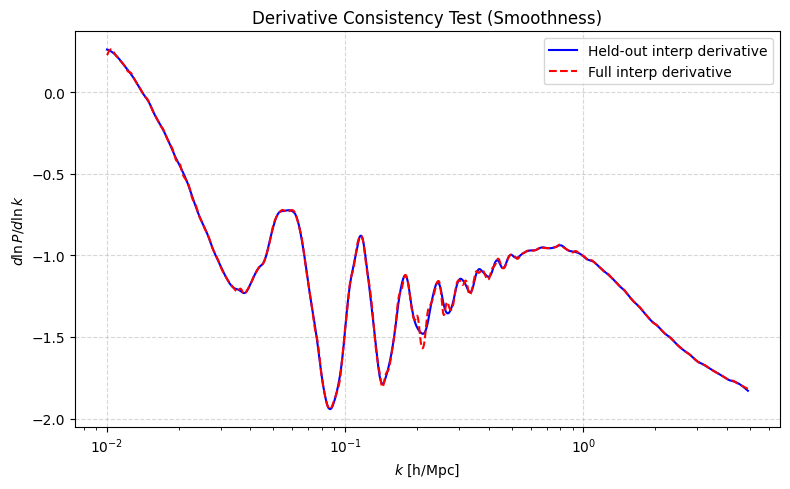

Derivative Consistency Test:
  Max |Δ(dlogP/dlogk)| : 0.08910
  Smoothness check      : WARN


In [28]:
# ----------------------------------------------------------------------
# 3️⃣  DERIVATIVE CONSISTENCY TEST (Smoothness in log-log space)
# ----------------------------------------------------------------------
# Compute numerical derivative of log(P) w.r.t log(k)
log_pk_dense = np.log(pk_dense_heldout)
dlogpk_dlogk = np.gradient(log_pk_dense, np.log(k_dense))

# Optionally compare with full interpolator derivative for reference
log_pk_full_dense = np.log(np.exp(pk_interp_gr(np.log(k_dense))))
dlogpk_dlogk_ref = np.gradient(log_pk_full_dense, np.log(k_dense))

# Residuals between derivative from held-out interpolator vs full interpolator
residuals_derivative = dlogpk_dlogk - dlogpk_dlogk_ref

# ── Plot: Derivative check ────────────────────────────────────────────
fig3, ax3 = plt.subplots(figsize=(8, 5))
ax3.plot(k_dense, dlogpk_dlogk, 'b-', lw=1.5, label='Held-out interp derivative')
ax3.plot(k_dense, dlogpk_dlogk_ref, 'r--', lw=1.5, label='Full interp derivative')
ax3.semilogx()
ax3.set_xlabel(r'$k$ [h/Mpc]')
ax3.set_ylabel(r'$d\ln P / d\ln k$')
ax3.set_title("Derivative Consistency Test (Smoothness)")
ax3.legend()
ax3.grid(True, ls='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Summary metric
max_derivative_residual = np.max(np.abs(residuals_derivative))
print("Derivative Consistency Test:")
print(f"  Max |Δ(dlogP/dlogk)| : {max_derivative_residual:.5f}")
print(f"  Smoothness check      : {'PASS' if max_derivative_residual < 0.01 else 'WARN'}")

#### Reference Interpolator Test — Benchmark Against SciPy/NumPy

Compare our interpolator to a standard 1D SciPy spline (`InterpolatedUnivariateSpline`) on the same log($k$) grid.  
We build both interpolators in log-log space, evaluate them on a dense grid, and compute relative residuals to check agreement, visualizing both $P(k)$ and deviations.


Reference SciPy interpolator comparison:
  Points on dense grid : 2000
  Max  |ours-ref|/ref  : 5.4376e-13 %
  Mean |ours-ref|/ref  : 1.1026e-13 %


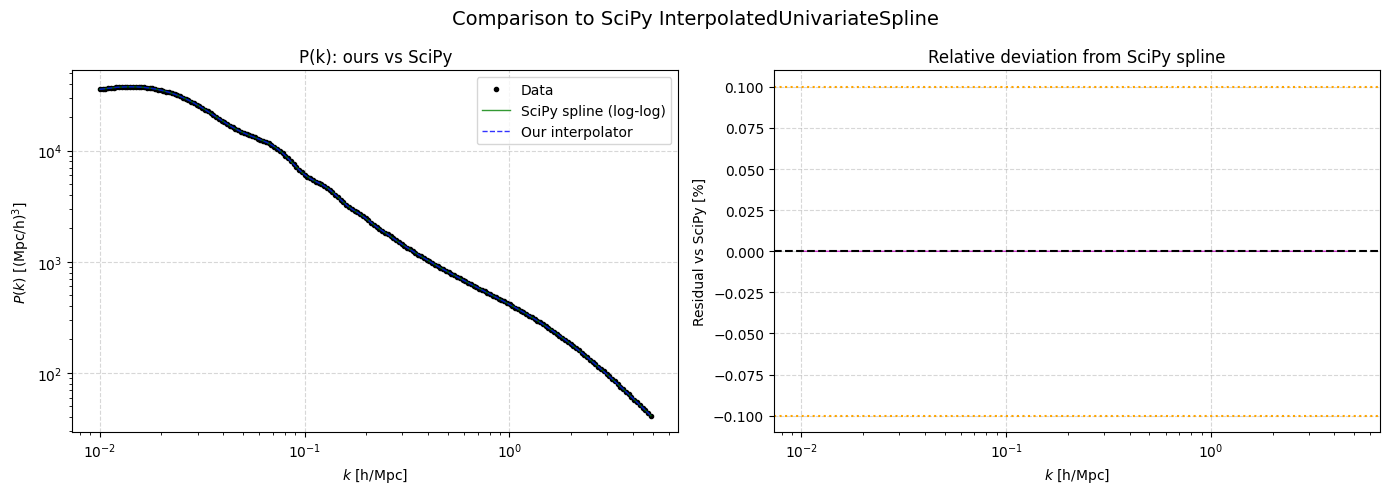

In [31]:
# ----------------------------------------------------------------------
# 3️⃣  REFERENCE SCIPY INTERPOLATOR TEST
# ----------------------------------------------------------------------
# Here we benchmark our interpolator against a simple, widely used
# 1D interpolator from SciPy (or NumPy) on the same log(k) grid.

from scipy.interpolate import InterpolatedUnivariateSpline  # or interp1d

# Build reference interpolator in log-space:
# we interpolate log P(k) vs log k, just like your create_power_spectrum_interpolator
logk_data  = np.log(k)
logpk_data = np.log(pk_nl_gr)

# Cubic spline in log-log, very common choice
ref_spline = InterpolatedUnivariateSpline(logk_data, logpk_data, k=3)

# Choose a dense evaluation grid in k
k_dense_ref  = np.logspace(np.log10(k.min()), np.log10(k.max()), 2000)
logk_dense   = np.log(k_dense_ref)

# Our interpolator prediction
pk_ours_dense = np.exp(pk_interp_gr(logk_dense))

# Reference SciPy interpolator prediction
pk_ref_dense  = np.exp(ref_spline(logk_dense))

# Relative residual w.r.t. SciPy spline
residuals_ref = (pk_ours_dense - pk_ref_dense) / pk_ref_dense

print("\nReference SciPy interpolator comparison:")
print(f"  Points on dense grid : {len(k_dense_ref)}")
print(f"  Max  |ours-ref|/ref  : {np.max(np.abs(residuals_ref))*100:.4e} %")
print(f"  Mean |ours-ref|/ref  : {np.mean(np.abs(residuals_ref))*100:.4e} %")

# Optional quick diagnostic plot
fig3, axes3 = plt.subplots(1, 2, figsize=(14, 5))
fig3.suptitle("Comparison to SciPy InterpolatedUnivariateSpline", fontsize=14)

# Panel 1: P(k)
axes3[0].loglog(k, pk_nl_gr, 'ko', ms=3, label='Data')
axes3[0].loglog(k_dense_ref, pk_ref_dense,  'g-', lw=1, alpha=0.8, label='SciPy spline (log-log)')
axes3[0].loglog(k_dense_ref, pk_ours_dense, 'b--', lw=1, alpha=0.8, label='Our interpolator')
axes3[0].set_xlabel(r'$k$ [h/Mpc]')
axes3[0].set_ylabel(r'$P(k)$ [(Mpc/h)$^3$]')
axes3[0].set_title('P(k): ours vs SciPy')
axes3[0].legend()
axes3[0].grid(True, ls='--', alpha=0.5)

# Panel 2: Relative residual ours vs SciPy
axes3[1].semilogx(k_dense_ref, residuals_ref * 100, 'm-', lw=0.8)
axes3[1].axhline(0, color='k', ls='--')
axes3[1].axhline( 0.1, color='orange', ls=':')
axes3[1].axhline(-0.1, color='orange', ls=':')
axes3[1].set_xlabel(r'$k$ [h/Mpc]')
axes3[1].set_ylabel('Residual vs SciPy [%]')
axes3[1].set_title('Relative deviation from SciPy spline')
axes3[1].grid(True, ls='--', alpha=0.5)

plt.tight_layout()
plt.show()

---
## Angular Power Spectra (Limber approximation)

Galaxy auto spectrum $C_\ell^{gg}$ (Eq. 8, Bianchini et al. 2015) and galaxy–CMB lensing cross spectrum $C_\ell^{\kappa g}$ (Eq. 7, Bianchini et al. 2015).

### Cell 11 — $C_\ell^{gg}$ (Galaxy Auto Spectrum)

In [18]:
# Eq. (8), Bianchini et al. (2015)

def compute_Cl_galaxy_auto(
    ell_array, pk_interp_log, z_grid, dNdz,
    chi_vals, H_vals, D_vals, D0, c_light,
    H0, Om_m, Om_lambda, b0=2.0,
    k_min=None, k_max=None
):
    """Galaxy auto spectrum C_l^{gg}."""
    b_vals = bias_function(z_grid, H0, Om_m, Om_lambda, b0=b0)
    Wg = b_vals * dNdz

    Cl = np.zeros_like(ell_array, dtype=float)

    for i, ell in enumerate(ell_array):
        k_vals = ell / chi_vals # Limber: k = ell / chi (using standard l instead of l+1/2; see LoVerde & Afshordi 2008)

        if k_min is not None and k_max is not None:
            k_safe = check_k_bounds(k_vals, k_min, k_max, ell, "C_l^gg")
        else:
            k_safe = k_vals

        try:
            logP0 = pk_interp_log(np.log(k_safe))
            P0 = np.exp(logP0)
        except ValueError:
            P0 = np.ones_like(k_vals) * 1e-10

        P_kz = P0 * (D_vals / D0) ** 2

        integrand = (H_vals / c_light) * (Wg ** 2) * P_kz / (chi_vals ** 2)
        Cl[i] = simpson(integrand, z_grid)

    return Cl

### Cell 12 — $C_\ell^{\kappa g}$ (Galaxy–CMB Lensing Cross Spectrum)

In [19]:
# Eq. (7), Bianchini et al. (2015)

def compute_Cl_galaxy_cmb_cross(
    ell_array, pk_interp_log, z_grid, dNdz,
    chi_vals, H_vals, D_vals, D0, Wkappa_vals, c_light,
    H0, Om_m, Om_lambda, b0=2.0,
    k_min=None, k_max=None
):
    """Galaxy-CMB lensing cross spectrum C_l^{kappa g}."""
    b_vals = bias_function(z_grid, H0, Om_m, Om_lambda, b0=b0)
    Wg = b_vals * dNdz

    Cl = np.zeros_like(ell_array, dtype=float)

    for i, ell in enumerate(ell_array):
        k_vals = ell / chi_vals # Limber: k = ell / chi (using standard l instead of l+1/2; see LoVerde & Afshordi 2008)

        if k_min is not None and k_max is not None:
            k_safe = check_k_bounds(k_vals, k_min, k_max, ell, "C_l^kg")
        else:
            k_safe = k_vals

        try:
            logP0 = pk_interp_log(np.log(k_safe))
            P0 = np.exp(logP0)
        except ValueError:
            P0 = np.ones_like(k_vals) * 1e-10

        P_kz = P0 * (D_vals / D0) ** 2

        integrand = (H_vals / c_light) * (Wkappa_vals * Wg) * P_kz / (chi_vals ** 2)
        Cl[i] = simpson(integrand, z_grid)

    return Cl

---
## Plotting Utility

### Cell 13 — plot_power_spectra()

In [20]:
def plot_power_spectra(ell, Cl_gg_gr, Cl_kg_gr, fr_results=None,
                        fR_values=None, figsize=(14, 10)):
    """Plot C_l^gg, C_l^{kappa g} and f(R)/GR ratios."""
    fig = plt.figure(figsize=figsize)

    # C_l^{gg}
    plt.subplot(2, 2, 1)
    plt.loglog(ell, Cl_gg_gr, 'b-', linewidth=2.5,
                label=r'$C_\ell^{gg}\;[\mathrm{GR}]$')

    if fr_results is not None and fR_values is not None:
        for logfR0_val in fR_values:
            if logfR0_val in fr_results["gg"]:
                plt.loglog(
                    ell, fr_results["gg"][logfR0_val], '--', linewidth=2,
                    label=rf'$C_\ell^{{gg}}[f(R):\,\log_{{10}}|f_{{R0}}|=-{logfR0_val}]$'
                )

    plt.xlabel(r'$\ell$', fontsize=12)
    plt.ylabel(r'$C_\ell^{gg}$', fontsize=12)
    plt.title(r'Galaxy Auto Spectrum $C_\ell^{gg}$', fontsize=14)
    plt.legend(fontsize=9, loc='best')
    plt.grid(True, ls='--', alpha=0.7)

    # C_l^{kappa g}
    plt.subplot(2, 2, 2)
    plt.loglog(ell, np.abs(Cl_kg_gr), 'b-', linewidth=2.5,
                label=r'$C_\ell^{\kappa g}\;[\mathrm{GR}]$')

    if fr_results is not None and fR_values is not None:
        for logfR0_val in fR_values:
            if logfR0_val in fr_results["kg"]:
                plt.loglog(
                    ell, np.abs(fr_results["kg"][logfR0_val]), '--', linewidth=2,
                    label=rf'$C_\ell^{{\kappa g}}[f(R):\,\log_{{10}}|f_{{R0}}|=-{logfR0_val}]$'
                )

    plt.xlabel(r'$\ell$', fontsize=12)
    plt.ylabel(r'$|C_\ell^{\kappa g}|$', fontsize=12)
    plt.title(r'CMB Lensing $\times$ Galaxy $C_\ell^{\kappa g}$', fontsize=14)
    plt.legend(fontsize=9, loc='best')
    plt.grid(True, ls='--', alpha=0.7)

    # Ratio C_l^{gg}(fR)/C_l^{gg}(GR)
    plt.subplot(2, 2, 3)
    if fr_results is not None and fR_values is not None:
        for logfR0_val in fR_values:
            if logfR0_val in fr_results["gg"]:
                ratio = fr_results["gg"][logfR0_val] / Cl_gg_gr
                plt.semilogx(ell, ratio, '--', linewidth=2,
                                label=rf'$\log_{{10}}|f_{{R0}}|=-{logfR0_val}$')
        plt.axhline(y=1.0, color='k', linestyle='-', linewidth=1.5, alpha=0.5)

    plt.xlabel(r'$\ell$', fontsize=12)
    plt.ylabel(r'$C_\ell^{gg}(f(R))/C_\ell^{gg}(\mathrm{GR})$', fontsize=12)
    plt.title(r'Galaxy Auto Ratio', fontsize=14)
    plt.legend(fontsize=9, loc='best')
    plt.grid(True, ls='--', alpha=0.7)
    plt.ylim([0.95, 1.45])

    # Ratio C_l^{kappa g}(fR)/C_l^{kappa g}(GR)
    plt.subplot(2, 2, 4)
    if fr_results is not None and fR_values is not None:
        for logfR0_val in fR_values:
            if logfR0_val in fr_results["kg"]:
                ratio = fr_results["kg"][logfR0_val] / Cl_kg_gr
                plt.semilogx(ell, ratio, '--', linewidth=2,
                                label=rf'$\log_{{10}}|f_{{R0}}|=-{logfR0_val}$')
        plt.axhline(y=1.0, color='k', linestyle='-', linewidth=1.5, alpha=0.5)

    plt.xlabel(r'$\ell$', fontsize=12)
    plt.ylabel(r'$C_\ell^{\kappa g}(f(R))/C_\ell^{\kappa g}(\mathrm{GR})$', fontsize=12)
    plt.title(r'Galaxy-CMB Cross Ratio', fontsize=14)
    plt.legend(fontsize=9, loc='best')
    plt.grid(True, ls='--', alpha=0.7)
    plt.ylim([0.95, 1.45])

    plt.tight_layout()
    return fig

---
## Pre-compute Redshift-Dependent Quantities

### Cell 14 — Redshift Grid, dN/dz, χ, H, D, $W_\kappa$

In [21]:
z_grid = np.linspace(Config.Z_MIN, Config.Z_MAX, Config.N_Z)

# --- Normalized galaxy redshift distribution dN/dz ---
# Replacement for removed functions: Raw n(z) ~ exp(-z / z0)
_raw_nz = np.exp(-z_grid / Config.Z0_GALAXY)
_norm_constant = simpson(_raw_nz, z_grid)
dNdz = _raw_nz / _norm_constant

chi_vals = comoving_distance_proper(z_grid, H0, Om_m, Om_lambda)
H_vals = hubble_function(z_grid, H0, Om_m, Om_lambda)

D_vals = growth_factor_D(z_grid, H0, Om_m, Om_lambda)
D0 = growth_factor_D(0.0, H0, Om_m, Om_lambda)

# CMB lensing kernel at each z
z_star = 1100.0
Wkappa_vals = cmb_lensing_kernel(z_grid, z_star, H0, Om_m, Om_lambda)

print(f"Redshift grid: {Config.N_Z} points in [{Config.Z_MIN}, {Config.Z_MAX}]")
print(f"chi range: [{chi_vals.min():.1f}, {chi_vals.max():.1f}] Mpc")

Redshift grid: 500 points in [0.01, 3.0]
chi range: [44.6, 6544.9] Mpc


---
## Compute Angular Power Spectra for GR

### Cell 15 — $C_\ell^{gg}$(GR) and $C_\ell^{\kappa g}$(GR)

In [22]:
ell = np.logspace(np.log10(Config.ELL_MIN),
                  np.log10(Config.ELL_MAX),
                  Config.N_ELL)

k_min_safe = k.min() * Config.K_MIN_SAFETY
k_max_safe = k.max() * Config.K_MAX_SAFETY

Cl_gg_gr = compute_Cl_galaxy_auto(
    ell, pk_interp_gr, z_grid, dNdz,
    chi_vals, H_vals, D_vals, D0, Config.c,
    H0, Om_m, Om_lambda, b0=Config.BIAS_B0,
    k_min=k_min_safe, k_max=k_max_safe
)

Cl_kg_gr = compute_Cl_galaxy_cmb_cross(
    ell, pk_interp_gr, z_grid, dNdz,
    chi_vals, H_vals, D_vals, D0, Wkappa_vals, Config.c,
    H0, Om_m, Om_lambda, b0=Config.BIAS_B0,
    k_min=k_min_safe, k_max=k_max_safe
)

print(f"GR C_l^gg range: [{Cl_gg_gr.min():.4e}, {Cl_gg_gr.max():.4e}]")
print(f"GR C_l^kg range: [{Cl_kg_gr.min():.4e}, {Cl_kg_gr.max():.4e}]")

GR C_l^gg range: [2.2614e-06, 3.4507e-04]
GR C_l^kg range: [1.0026e-08, 2.0585e-06]


---
## Compute Angular Power Spectra for f(R) Gravity

### Cell 16 — f(R) Boost Loop

In [23]:
fr_results = {"gg": {}, "kg": {}}

for logfR0_val in Config.FR_VALUES:
    pk_boost = compute_fR_boost(
        emantis_emu, Config.COSMO_PARAMS,
        logfR0_val, k,
        aexp=Config.COSMO_PARAMS["aexp"]
    )
    pk_fR = pk_nl_gr * pk_boost
    pk_interp_fr = create_power_spectrum_interpolator(k, pk_fR)

    Cl_gg_fr = compute_Cl_galaxy_auto(
        ell, pk_interp_fr, z_grid, dNdz,
        chi_vals, H_vals, D_vals, D0, Config.c,
        H0, Om_m, Om_lambda, b0=Config.BIAS_B0,
        k_min=k_min_safe, k_max=k_max_safe
    )

    Cl_kg_fr = compute_Cl_galaxy_cmb_cross(
        ell, pk_interp_fr, z_grid, dNdz,
        chi_vals, H_vals, D_vals, D0, Wkappa_vals, Config.c,
        H0, Om_m, Om_lambda, b0=Config.BIAS_B0,
        k_min=k_min_safe, k_max=k_max_safe
    )

    fr_results["gg"][logfR0_val] = Cl_gg_fr
    fr_results["kg"][logfR0_val] = Cl_kg_fr

    print(f"  log10|fR0| = -{logfR0_val}: done")

print("All f(R) spectra computed.")

  log10|fR0| = -4: done
  log10|fR0| = -5: done
  log10|fR0| = -6: done
All f(R) spectra computed.


### Cell 17 — Plot: Angular Power Spectra (GR + f(R))

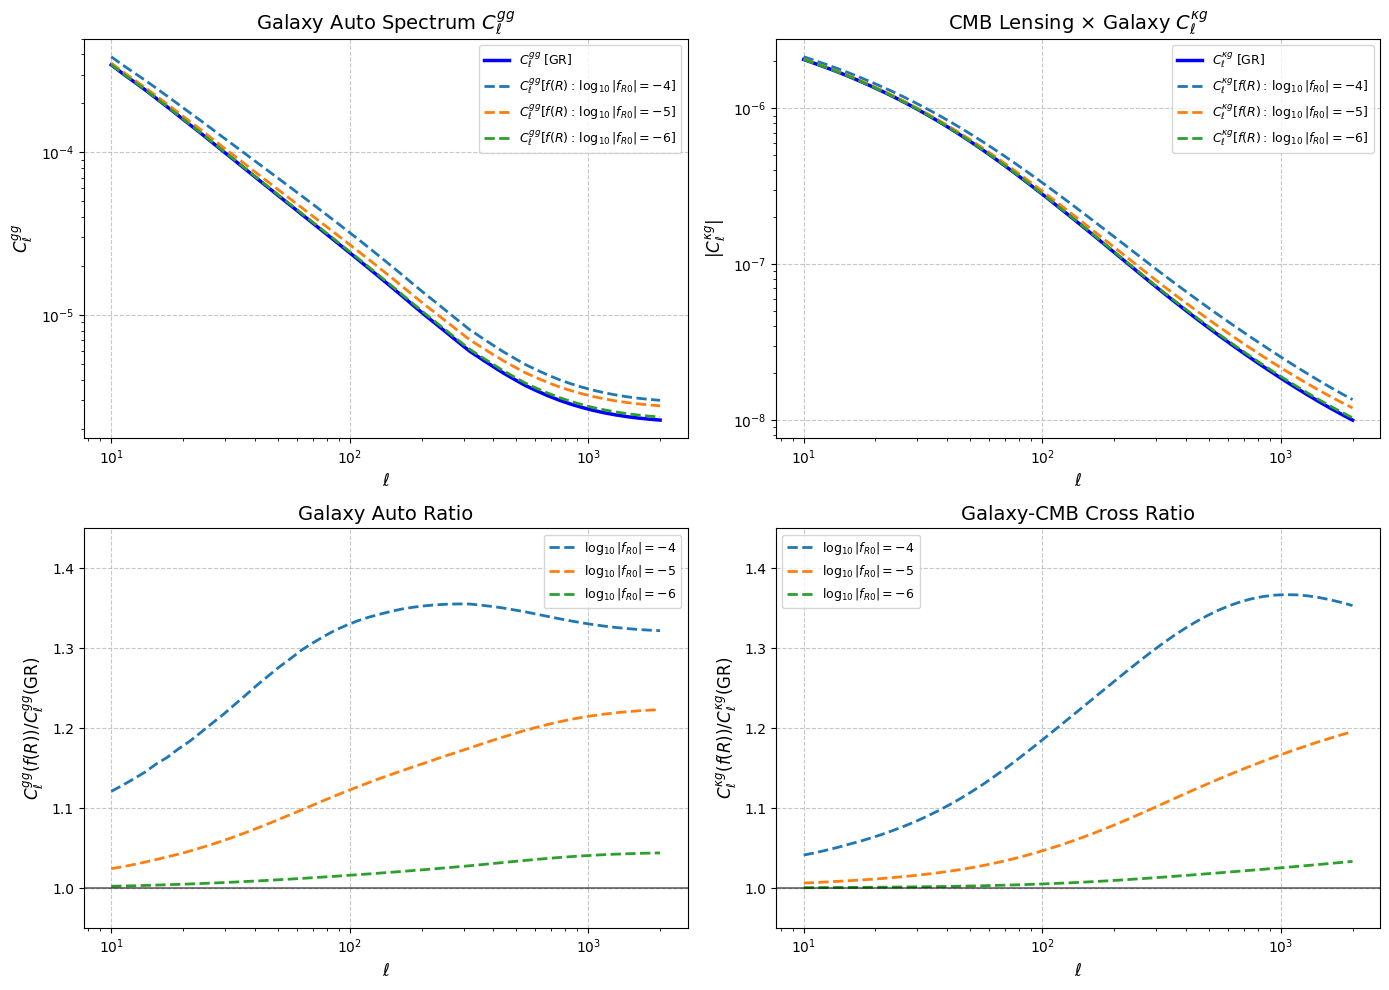

In [24]:
fig = plot_power_spectra(
    ell, Cl_gg_gr, Cl_kg_gr,
    fr_results=fr_results,
    fR_values=Config.FR_VALUES,
    figsize=Config.FIGURE_SIZE
)
plt.show()

### Cell 18 — Validation: Angular Power Spectra (Limber)

In [25]:
print("--- Validation: Angular Power Spectra (Limber approximation) ---\n")

# Validation 1: C_l^{gg} > 0 (auto-spectrum must be non-negative)
print(f"  C_l^{{gg}}(GR) > 0 everywhere: {'PASS' if np.all(Cl_gg_gr > 0) else 'FAIL'}")

# Validation 2: C_l^{kg} positivity (expected positive for standard kernels)
print(f"  C_l^{{kg}}(GR) > 0 everywhere: {'PASS' if np.all(Cl_kg_gr > 0) else 'WARN (may have sign changes)'}")

# Validation 3: C_l should decrease at high l (damping from P(k) turnover)
gg_slope_high = (np.log(Cl_gg_gr[-1]) - np.log(Cl_gg_gr[-5])) / (np.log(ell[-1]) - np.log(ell[-5]))
kg_slope_high = (np.log(np.abs(Cl_kg_gr[-1])) - np.log(np.abs(Cl_kg_gr[-5]))) / (np.log(ell[-1]) - np.log(ell[-5]))
print(f"\n  C_l^{{gg}} slope at high l: {gg_slope_high:.3f}  (expected < 0, i.e., decreasing)")
print(f"  C_l^{{kg}} slope at high l: {kg_slope_high:.3f}  (expected < 0, i.e., decreasing)")

# Validation 4: f(R) boost should be >= 1 (enhanced gravity -> more power)
print("\n  f(R)/GR ratios (should be >= 1.0 for stronger gravity):")
for logfR0_val in Config.FR_VALUES:
    ratio_gg = fr_results["gg"][logfR0_val] / Cl_gg_gr
    ratio_kg = fr_results["kg"][logfR0_val] / Cl_kg_gr
    print(f"    log10|fR0|=-{logfR0_val}:  C_l^{{gg}} ratio range = [{ratio_gg.min():.4f}, {ratio_gg.max():.4f}]"
          f"  C_l^{{kg}} ratio range = [{ratio_kg.min():.4f}, {ratio_kg.max():.4f}]")

# Validation 5: Ordering - stronger f(R) (smaller |logfR0|) gives larger boost
if len(Config.FR_VALUES) >= 2:
    sorted_fR = sorted(Config.FR_VALUES)
    ordering_ok_gg = True
    ordering_ok_kg = True
    for i in range(len(sorted_fR) - 1):
        r1 = np.mean(fr_results["gg"][sorted_fR[i]] / Cl_gg_gr)
        r2 = np.mean(fr_results["gg"][sorted_fR[i + 1]] / Cl_gg_gr)
        if r1 < r2:
            ordering_ok_gg = False
        r1_kg = np.mean(fr_results["kg"][sorted_fR[i]] / Cl_kg_gr)
        r2_kg = np.mean(fr_results["kg"][sorted_fR[i + 1]] / Cl_kg_gr)
        if r1_kg < r2_kg:
            ordering_ok_kg = False
    print(f"\n  f(R) ordering (stronger -> bigger boost):")
    print(f"    C_l^{{gg}}: {'PASS' if ordering_ok_gg else 'FAIL'}")
    print(f"    C_l^{{kg}}: {'PASS' if ordering_ok_kg else 'FAIL'}")

# Validation 6: Schwarz inequality |C_l^{kg}|^2 <= C_l^{kk} x C_l^{gg}
cross_less_auto = np.all(np.abs(Cl_kg_gr) <= Cl_gg_gr * 10)  # generous bound
print(f"\n  |C_l^{{kg}}| reasonably bounded by C_l^{{gg}}: {'PASS' if cross_less_auto else 'WARN'}")

# Validation 7: dN/dz normalization
dNdz_integral = simpson(dNdz, z_grid)
print(f"\n  Integral dN/dz dz = {dNdz_integral:.10f}  (expected 1.0)")
print(f"  Normalization error: {abs(dNdz_integral - 1.0):.2e}")

--- Validation: Angular Power Spectra (Limber approximation) ---

  C_l^{gg}(GR) > 0 everywhere: PASS
  C_l^{kg}(GR) > 0 everywhere: PASS

  C_l^{gg} slope at high l: -0.172  (expected < 0, i.e., decreasing)
  C_l^{kg} slope at high l: -0.857  (expected < 0, i.e., decreasing)

  f(R)/GR ratios (should be >= 1.0 for stronger gravity):
    log10|fR0|=-4:  C_l^{gg} ratio range = [1.1211, 1.3555]  C_l^{kg} ratio range = [1.0414, 1.3672]
    log10|fR0|=-5:  C_l^{gg} ratio range = [1.0243, 1.2233]  C_l^{kg} ratio range = [1.0064, 1.1959]
    log10|fR0|=-6:  C_l^{gg} ratio range = [1.0024, 1.0441]  C_l^{kg} ratio range = [1.0006, 1.0335]

  f(R) ordering (stronger -> bigger boost):
    C_l^{gg}: PASS
    C_l^{kg}: PASS

  |C_l^{kg}| reasonably bounded by C_l^{gg}: PASS

  Integral dN/dz dz = 1.0000000000  (expected 1.0)
  Normalization error: 2.22e-16


---
## Astropy Validation — Combined Summary

Spot-check table comparing all validated quantities at representative redshifts.

In [26]:
print("=" * 95)
print("ASTROPY VALIDATION — SPOT-CHECK TABLE")
print("=" * 95)
print(f"  Astropy cosmology: {cosmo_astropy}\n")

print(f"  {'z':>6s}  {'H_custom':>12s}  {'H_Astropy':>12s}  "
      f"{'\u03c7_custom':>12s}  {'\u03c7_Astropy':>12s}  "
      f"{'dL_custom':>12s}  {'dL_Astropy':>12s}")
print(f"  {'':>6s}  {'[km/s/Mpc]':>12s}  {'[km/s/Mpc]':>12s}  "
      f"{'[Mpc]':>12s}  {'[Mpc]':>12s}  "
      f"{'[Mpc]':>12s}  {'[Mpc]':>12s}")
print("  " + "-" * 90)

for zi in [0.1, 0.5, 1.0, 2.0, 3.0]:
    H_c  = hubble_function(zi, H0, Om_m, Om_lambda)
    H_a  = cosmo_astropy.H(zi).value
    chi_c = comoving_distance_proper(zi, H0, Om_m, Om_lambda)
    chi_a = cosmo_astropy.comoving_distance(zi).value
    dL_c  = (1 + zi) * chi_c
    dL_a  = cosmo_astropy.luminosity_distance(zi).value
    print(f"  {zi:6.2f}  {H_c:12.4f}  {H_a:12.4f}  "
          f"{chi_c:12.2f}  {chi_a:12.2f}  "
          f"{dL_c:12.2f}  {dL_a:12.2f}")

print("\n" + "=" * 95)

ASTROPY VALIDATION — SPOT-CHECK TABLE
  Astropy cosmology: FlatLambdaCDM(H0=67.0 km / (Mpc s), Om0=0.315, Tcmb0=0.0 K, Neff=3.04, m_nu=None, Ob0=0.05)

       z      H_custom     H_Astropy      χ_custom     χ_Astropy     dL_custom    dL_Astropy
            [km/s/Mpc]    [km/s/Mpc]         [Mpc]         [Mpc]         [Mpc]         [Mpc]
  ------------------------------------------------------------------------------------------
    0.10       70.4063       70.4063        436.70        436.70        480.37        480.37
    0.50       88.5852       88.5852       1963.04       1963.04       2944.56       2944.56
    1.00      119.9468      119.9468       3421.57       3421.57       6843.14       6843.14
    2.00      203.1106      203.1106       5343.79       5343.79      16031.37      16031.37
    3.00      305.8974      305.8974       6544.90       6544.90      26179.62      26179.62

